# Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

Loads tools like Pandas, NumPy, Matplotlib, Seaborn, and
Scikit learn that will be used throughout the project.
these are all the important libraries that are used for data analysis visualization ,preprocessing of data ,model traning and avaluation.

# Load the Dataset

In [24]:
df = pd.read_csv("../data/Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


 TARGET VARIABLE:
 price (Indian Rupees (INR))

 FEATURES:
 Numerical Features:
 - area (square feet (sq ft))
 - bedrooms
 - bathrooms
 - stories
 - parking

 Categorical Features:
 - mainroad
 - guestroom
 - basement
 - hotwaterheating
 - airconditioning
 - prefarea
 - furnishingstatus


# Data Preprocessing

In [25]:
#Data cleaning
print("null values")
print(df.isnull().sum())
print("duplicated values")
print(df.duplicated().sum())
print("unique values")
print(df.nunique())
print(df.describe())


null values
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
duplicated values
0
unique values
price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1

-this code block checks the dataset for missing values ,duplicate values unique values and the data types.
-this cleans the data which improves the accuracy and prevents incorrect prediction which might be caused by incosostet or incomplete data.

In [26]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


Convert categorical variables into numerical values using one hot Encoding.this is because regression models cannot work directly with text.

# Exploratory Data Analysis (EDA)

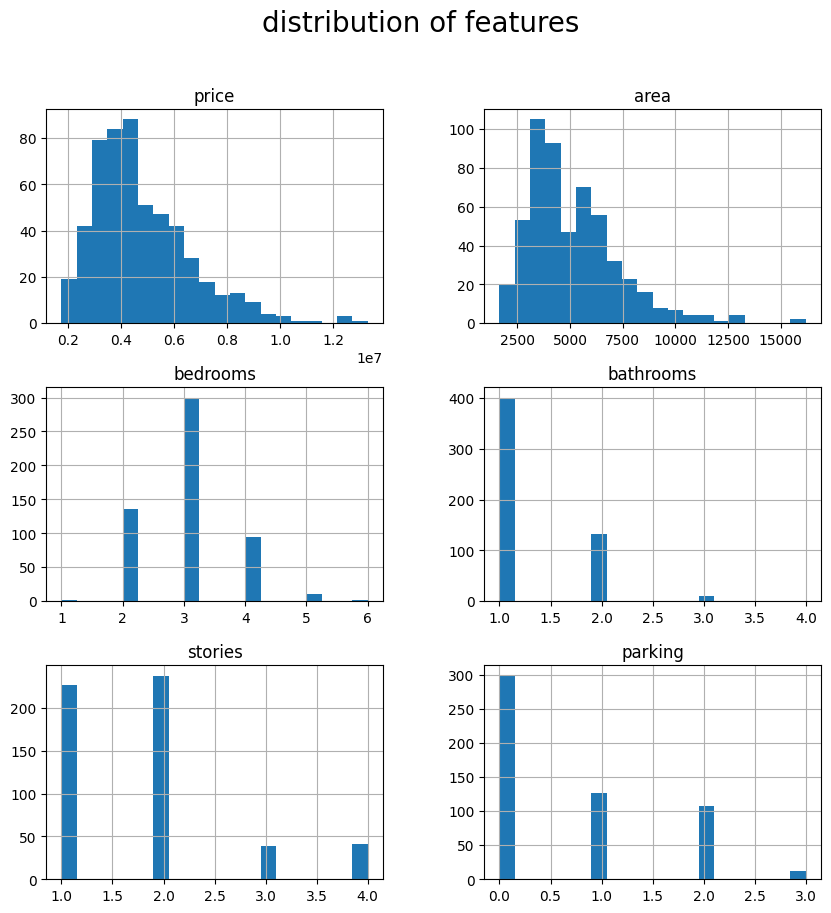

In [27]:
df.hist(figsize=(10,10),bins=20)
plt.suptitle("distribution of features",fontsize=20)
plt .show()

we have displayed a histogram for each variable which shows the spread of values across each variable .this help us to identify the skewness,outliers and overall distribution of data before the traning phase.

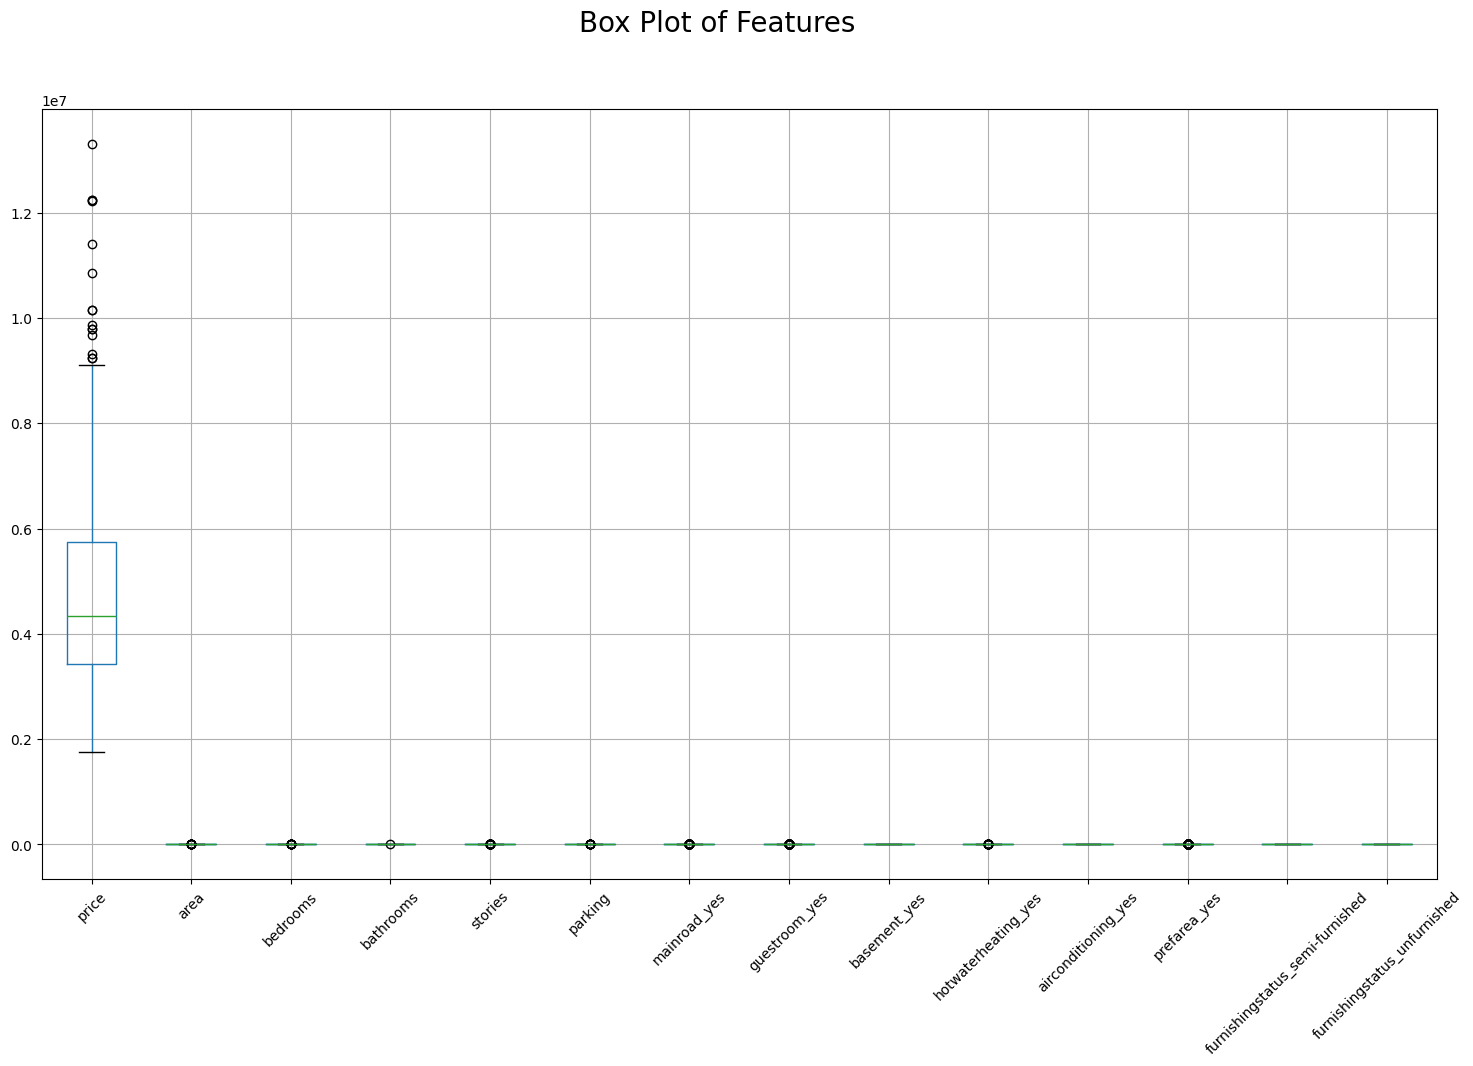

In [28]:
plt.figure(figsize=(18,10))
df.boxplot(rot=45)
plt.suptitle("Box Plot of Features", fontsize=20)
plt.show()

-this plots the outliers in each numerical features .it displays the median ,quartiles and possible outliers for every feature.the outliers can effect the regression model and ca reduce prediction accuracy.

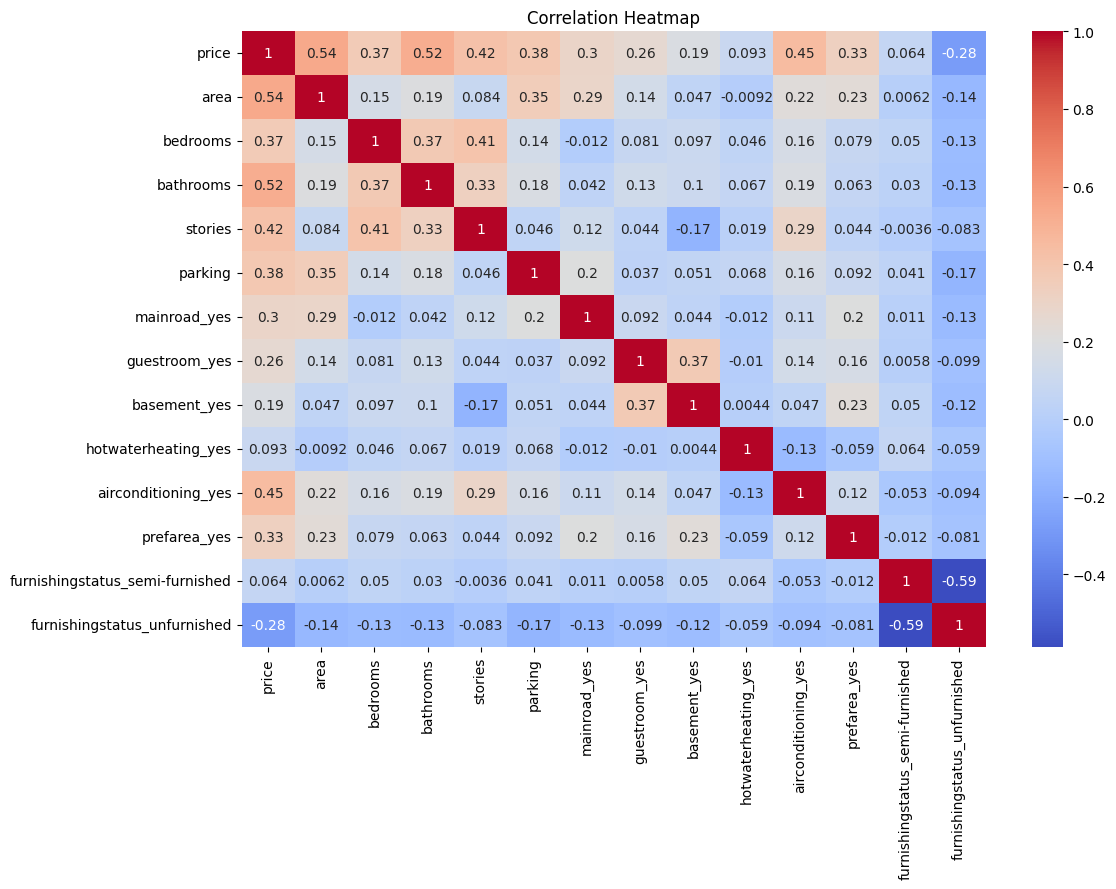

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [30]:
X = df.drop(
    "price",
    axis=1
)
y = df["price"]

# Feature Engineering

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (436, 13)
Testing Shape: (109, 13)


In [32]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)
target_scaler = MinMaxScaler()
y_train = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test = target_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

# Model Training (linear regression)

In [33]:
linear_model = LinearRegression()
linear_model.fit(x_train_scaled, y_train)
y_pred_linear = linear_model.predict(x_test_scaled)

# Model Evaluation

In [34]:
mae = mean_absolute_error(y_test, y_pred_linear)
mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_linear)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.09238508608763475
MSE : 0.015912187640187474
RMSE: 0.12614352000870863
R2 Score: 0.6529242642153175


# Cross Validation


In [35]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
cv_scores = cross_val_score(
    linear_model,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring="r2"
)
print("Cross Validation R² Scores:")
print(cv_scores)
print("\nAverage R² Score:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation R² Scores:
[0.63380889 0.59552526 0.73036386 0.65767464 0.62779901]

Average R² Score: 0.6490343335414055
Standard Deviation: 0.04524404954476413


# Model Visualization

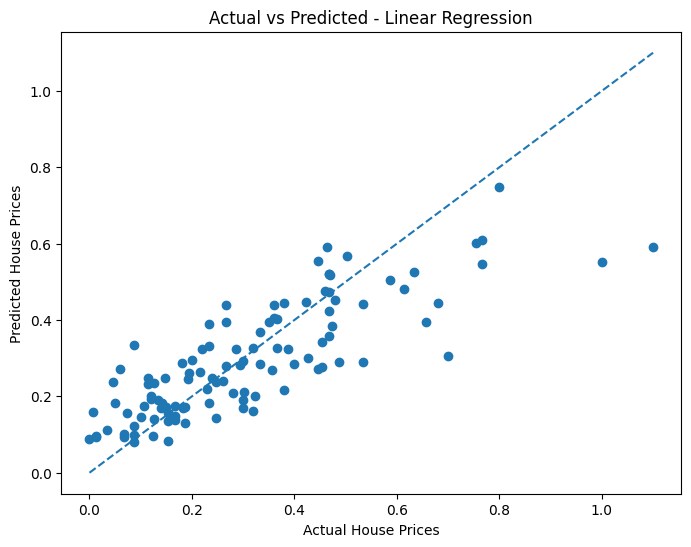

In [36]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_linear)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

# Model Evaluation ( ridge regression)

In [37]:
ridge_model = Ridge(random_state=42)
ridge_model.fit(x_train_scaled, y_train)
y_pred_ridge = ridge_model.predict(x_test_scaled)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, y_pred_ridge)
print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE:", ridge_rmse)
print("R² Score:", ridge_r2)

MAE : 0.09137506873557803
MSE : 0.015937370468297046
RMSE: 0.1262432987064939
R² Score: 0.652374977794562


In [38]:
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ridge_cv_scores = cross_val_score(
    ridge_model,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring="r2"
)

print("Cross Validation R² Scores:")
print(ridge_cv_scores)

print("\nAverage R² Score:", ridge_cv_scores.mean())
print("Standard Deviation:", ridge_cv_scores.std())

Cross Validation R² Scores:
[0.63427301 0.60432319 0.71190096 0.65492714 0.6408438 ]

Average R² Score: 0.6492536184184681
Standard Deviation: 0.03541402315460879


In [39]:
ridge_params = {
    "alpha": [0.01, 0.1, 1, 10, 100]
}

ridge_grid = GridSearchCV(
    estimator=Ridge(random_state=42),
    param_grid=ridge_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(x_train_scaled, y_train)

print("Best Parameters:", ridge_grid.best_params_)
print("Best Cross Validation R²:", ridge_grid.best_score_)

Best Parameters: {'alpha': 1}
Best Cross Validation R²: 0.648854452557952


In [40]:
best_ridge = ridge_grid.best_estimator_
best_ridge.fit(x_train_scaled, y_train)
best_ridge_predictions = best_ridge.predict(x_test_scaled)

In [41]:
best_mae = mean_absolute_error(y_test, best_ridge_predictions)
best_mse = mean_squared_error(y_test, best_ridge_predictions)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_ridge_predictions)
print("Tuned Ridge Regression Performance")
print("-" * 40)
print("MAE :", best_mae)
print("MSE :", best_mse)
print("RMSE:", best_rmse)
print("R² Score:", best_r2)

Tuned Ridge Regression Performance
----------------------------------------
MAE : 0.09137506873557803
MSE : 0.015937370468297046
RMSE: 0.1262432987064939
R² Score: 0.652374977794562


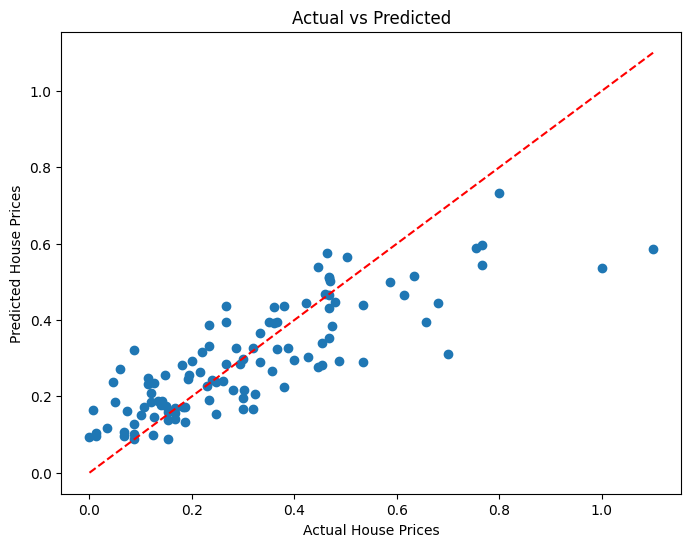

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, best_ridge_predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted")
plt.show()

# Model Training & evaluation (Lasso regression)

In [43]:
lasso_model = Lasso(random_state=42)
lasso_model.fit(x_train_scaled, y_train)
y_pred_lasso = lasso_model.predict(x_test_scaled)

In [44]:
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, y_pred_lasso)
print("MAE :", lasso_mae)
print("MSE :", lasso_mse)
print("RMSE:", lasso_rmse)
print("R² Score:", lasso_r2)

MAE : 0.16653567685099457
MSE : 0.04666827076849217
RMSE: 0.2160284026893042
R² Score: -0.0179256794248297


In [45]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
lasso_cv_scores = cross_val_score(
    lasso_model,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring="r2"
)
print("Cross Validation R² Scores:")
print(lasso_cv_scores)
print("\nAverage R² Score:", lasso_cv_scores.mean())
print("Standard Deviation:", lasso_cv_scores.std())

Cross Validation R² Scores:
[-0.01722297 -0.0502488  -0.00170986 -0.00811991 -0.01784304]

Average R² Score: -0.019028919822195255
Standard Deviation: 0.01672306741874207


In [46]:
lasso_params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10]
}

lasso_grid = GridSearchCV(
    estimator=Lasso(random_state=42, max_iter=10000),
    param_grid=lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(x_train_scaled, y_train)

print("Best Parameters:", lasso_grid.best_params_)
print("Best Cross Validation R²:", lasso_grid.best_score_)

Best Parameters: {'alpha': 0.0001}
Best Cross Validation R²: 0.6474070314577224


In [47]:
best_lasso = lasso_grid.best_estimator_
best_lasso.fit(x_train_scaled, y_train)
best_lasso_predictions = best_lasso.predict(x_test_scaled)

In [48]:
best_lasso_mae = mean_absolute_error(y_test, best_lasso_predictions)
best_lasso_mse = mean_squared_error(y_test, best_lasso_predictions)
best_lasso_rmse = np.sqrt(best_lasso_mse)
best_lasso_r2 = r2_score(y_test, best_lasso_predictions)
print("Tuned Lasso Regression Performance")
print("MAE :", best_lasso_mae)
print("MSE :", best_lasso_mse)
print("RMSE:", best_lasso_rmse)
print("R² Score:", best_lasso_r2)

Tuned Lasso Regression Performance
MAE : 0.09240668101464435
MSE : 0.015961147106391956
RMSE: 0.12633743351197205
R² Score: 0.6518563631107811


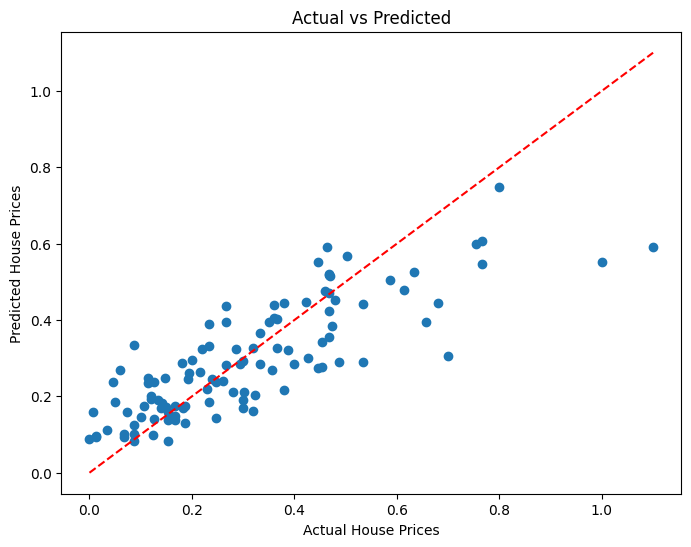

In [49]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, best_lasso_predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted")
plt.show()

# Model training & evaluation ( elastic model)

In [50]:
elastic_model = ElasticNet(random_state=42)
elastic_model.fit(x_train_scaled, y_train)
y_pred_elastic = elastic_model.predict(x_test_scaled)

In [51]:

elastic_mae = mean_absolute_error(y_test, y_pred_elastic)
elastic_mse = mean_squared_error(y_test, y_pred_elastic)
elastic_rmse = np.sqrt(elastic_mse)
elastic_r2 = r2_score(y_test, y_pred_elastic)

print("ElasticNet Regression Performance")
print("MAE :", elastic_mae)
print("MSE :", elastic_mse)
print("RMSE:", elastic_rmse)
print("R² Score:", elastic_r2)

ElasticNet Regression Performance
MAE : 0.16653567685099457
MSE : 0.04666827076849217
RMSE: 0.2160284026893042
R² Score: -0.0179256794248297


In [52]:
elastic_results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [elastic_mae, elastic_mse, elastic_rmse, elastic_r2]
})

elastic_results

,Metric,Value
0,MAE,0.166536
1,MSE,0.046668
2,RMSE,0.216028
3,R² Score,-0.017926


In [53]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

elastic_cv_scores = cross_val_score(
    elastic_model,
    x_train_scaled,
    y_train,
    cv=cv,
    scoring="r2"
)

print("Cross Validation R² Scores:")
print(elastic_cv_scores)

print("\nAverage R² Score:", elastic_cv_scores.mean())
print("Standard Deviation:", elastic_cv_scores.std())

Cross Validation R² Scores:
[-0.01722297 -0.0502488  -0.00170986 -0.00811991 -0.01784304]

Average R² Score: -0.019028919822195255
Standard Deviation: 0.01672306741874207


In [54]:
elastic_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10],
    "l1_ratio": [0.2, 0.4, 0.6, 0.8, 1.0]
}

elastic_grid = GridSearchCV(
    estimator=ElasticNet(random_state=42, max_iter=10000),
    param_grid=elastic_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(x_train_scaled, y_train)

print("Best Parameters:", elastic_grid.best_params_)
print("Best Cross Validation R²:", elastic_grid.best_score_)

Best Parameters: {'alpha': 0.001, 'l1_ratio': 0.2}
Best Cross Validation R²: 0.6484507857067882


In [55]:

best_elastic = elastic_grid.best_estimator_

best_elastic.fit(x_train_scaled, y_train)

best_elastic_predictions = best_elastic.predict(x_test_scaled)

In [56]:

best_elastic_mae = mean_absolute_error(y_test, best_elastic_predictions)
best_elastic_mse = mean_squared_error(y_test, best_elastic_predictions)
best_elastic_rmse = np.sqrt(best_elastic_mse)
best_elastic_r2 = r2_score(y_test, best_elastic_predictions)

print("Tuned ElasticNet Regression Performance")
print("MAE :", best_elastic_mae)
print("MSE :", best_elastic_mse)
print("RMSE:", best_elastic_rmse)
print("R² Score:", best_elastic_r2)


Tuned ElasticNet Regression Performance
MAE : 0.09203196356799988
MSE : 0.01601530914114908
RMSE: 0.12655160663203405
R² Score: 0.6506749838755685


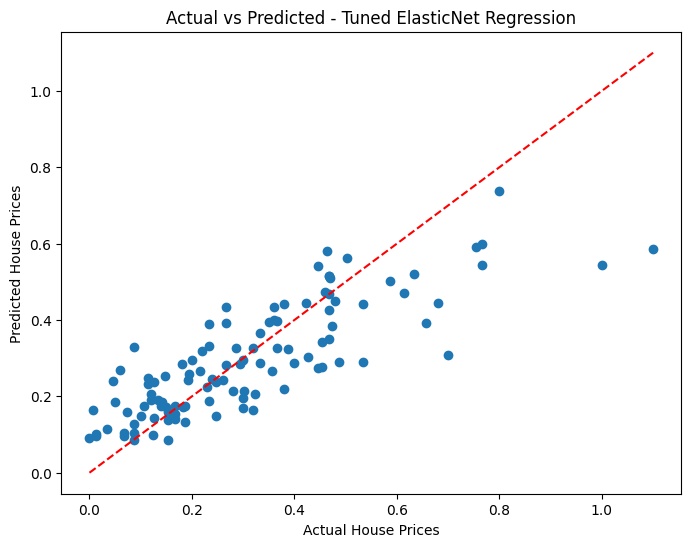

In [57]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, best_elastic_predictions)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted - Tuned ElasticNet Regression")

plt.show()

In [58]:
comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression"
    ],
    "MAE": [
        mae,
        best_mae,
        best_lasso_mae,
        best_elastic_mae
    ],
    "MSE": [
        mse,
        best_mse,
        best_lasso_mse,
        best_elastic_mse
    ],
    "RMSE": [
        rmse,
        best_rmse,
        best_lasso_rmse,
        best_elastic_rmse
    ],
    "R² Score": [
        r2,
        best_r2,
        best_lasso_r2,
        best_elastic_r2
    ]
})

comparison_df



,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.092385,0.015912,0.126144,0.652924
1,Ridge Regression,0.091375,0.015937,0.126243,0.652375
2,Lasso Regression,0.092407,0.015961,0.126337,0.651856
3,ElasticNet Regression,0.092032,0.016015,0.126552,0.650675


In [59]:
cv_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression"
    ],
    "Mean CV R²": [
        cv_scores.mean(),
        ridge_cv_scores.mean(),
        lasso_cv_scores.mean(),
        elastic_cv_scores.mean()
    ],
    "Std CV": [
        cv_scores.std(),
        ridge_cv_scores.std(),
        lasso_cv_scores.std(),
        elastic_cv_scores.std()
    ]
})

cv_results

,Model,Mean CV R²,Std CV
0,Linear Regression,0.649034,0.045244
1,Ridge Regression,0.649254,0.035414
2,Lasso Regression,-0.019029,0.016723
3,ElasticNet Regression,-0.019029,0.016723


In [60]:
best_parameters = pd.DataFrame({
    "Model": [
        "Ridge Regression",
        "Lasso Regression",
        "ElasticNet Regression"
    ],
    "Best Parameters": [
        ridge_grid.best_params_,
        lasso_grid.best_params_,
        elastic_grid.best_params_
    ]
})

best_parameters

,Model,Best Parameters
0,Ridge Regression,{'alpha': 1}
1,Lasso Regression,{'alpha': 0.0001}
2,ElasticNet Regression,"{'alpha': 0.001, 'l1_ratio': 0.2}"


In [61]:
best_model = comparison_df.loc[
    comparison_df["R² Score"].idxmax()
]
print("Best Regression Model")
print(best_model)

Best Regression Model
Model       Linear Regression
MAE                  0.092385
MSE                  0.015912
RMSE                 0.126144
R² Score             0.652924
Name: 0, dtype: object


In [62]:
best_model_name = comparison_df.loc[
    comparison_df["R² Score"].idxmax(), "Model"
]

if best_model_name == "Linear Regression":
    best_model = linear_model
elif best_model_name == "Ridge Regression":
    best_model = ridge_model
elif best_model_name == "Lasso Regression":
    best_model = lasso_model
elif best_model_name == "ElasticNet Regression":
    best_model = elastic_model

print(best_model)

LinearRegression()


In [63]:
import joblib

joblib.dump(best_model, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(target_scaler, "target_scaler.pkl")

['target_scaler.pkl']

In [64]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [65]:
joblib.dump(target_scaler, "target_scaler.pkl")

['target_scaler.pkl']